# Monte Carlo PnL Simulation

This notebook simulates possible PnL paths by fitting to the historical `pnl` values in a CSV (e.g., `vol_gp\artifacts\variance_proxy_trades.csv`).
The simulation uses **bootstrap resampling** of observed PnL by default, so it matches the empirical distribution.


In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from yfinance_utils import get_history

plt.style.use("seaborn-v0_8")


## Config


In [22]:
CSV_PATH = r"..\return_gp\artifacts\AAPL\return_gp_trades.csv"
N_PATHS = 300
N_STEPS = 252
SEED = 7

# Choose how to fit pnl distribution
FIT_METHOD = "normal"  # "bootstrap" or "normal"


In [23]:
df = pd.read_csv(CSV_PATH)
if "pnl" not in df.columns:
    raise ValueError("CSV must include a 'pnl' column.")

pnl = df["pnl"].dropna().astype(float).to_numpy()
if pnl.size == 0:
    raise ValueError("No pnl values found after dropping NaNs.")

pd.Series(pnl).describe()


count    231.000000
mean       1.075431
std       10.539417
min      -35.428841
25%       -5.937129
50%        0.488977
75%        8.016576
max       47.228483
dtype: float64

In [24]:
rng = np.random.default_rng(SEED)

if FIT_METHOD == "bootstrap":
    # Empirical resampling of observed pnl values
    samples = rng.choice(pnl, size=(N_STEPS, N_PATHS), replace=True)
elif FIT_METHOD == "normal":
    # Parametric fit to mean/std of pnl
    mu = pnl.mean()
    sigma = pnl.std(ddof=1)
    samples = rng.normal(mu, sigma, size=(N_STEPS, N_PATHS))
else:
    raise ValueError("FIT_METHOD must be 'bootstrap' or 'normal'.")

paths = samples.cumsum(axis=0)
paths.shape


(252, 300)

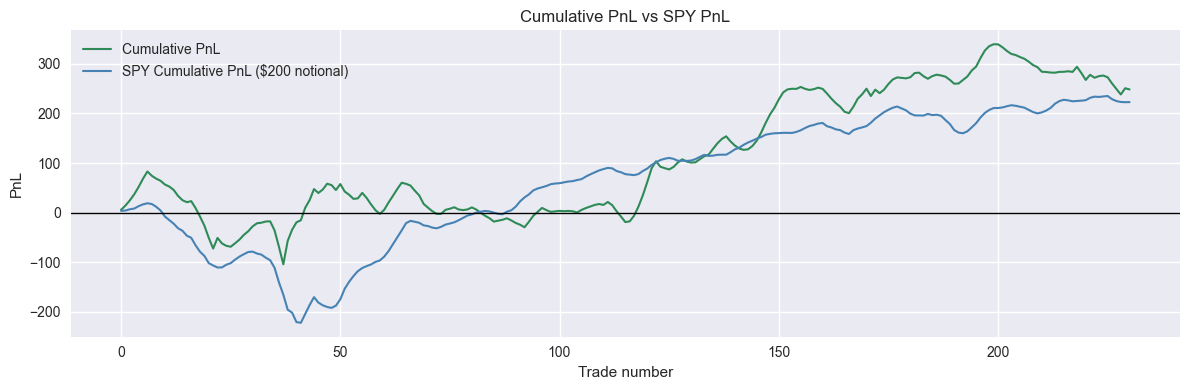

In [25]:
# Plot cumulative PnL and SPY $ PnL in correct trade order
trade_order = df.copy()
if "trade_date" in trade_order.columns:
    trade_order["trade_date"] = pd.to_datetime(trade_order["trade_date"], errors="coerce")
if "exit_date" in trade_order.columns:
    trade_order["exit_date"] = pd.to_datetime(trade_order["exit_date"], errors="coerce")

sort_cols = [col for col in ["trade_date", "exit_date"] if col in trade_order.columns]
if sort_cols:
    trade_order = trade_order.sort_values(sort_cols, kind="mergesort")

trade_order = trade_order.reset_index(drop=True)
if "pnl" not in trade_order.columns:
    raise ValueError("CSV must include a 'pnl' column to plot cumulative PnL.")
if "trade_date" not in trade_order.columns or "exit_date" not in trade_order.columns:
    raise ValueError("CSV must include both 'trade_date' and 'exit_date' columns to compare with SPY.")

if trade_order["trade_date"].isna().any() or trade_order["exit_date"].isna().any():
    raise ValueError("Found NaT in 'trade_date' or 'exit_date' after parsing.")

cum_pnl = trade_order["pnl"].astype(float).cumsum()

# Fetch SPY and compute $ PnL over each trade window
SPY_NOTIONAL = 270.0

spy_start = trade_order["trade_date"].min()
spy_end = trade_order["exit_date"].max()

spy_history = get_history(
    "SPY",
    period=None,
    start=str(pd.Timestamp(spy_start).date()),
    end=str((pd.Timestamp(spy_end) + pd.Timedelta(days=1)).date()),
    interval="1d",
    auto_adjust=True,
)

spy_close = spy_history["Close"].copy()
if isinstance(spy_close.index, pd.DatetimeIndex):
    idx = spy_close.index
    if idx.tz is not None:
        idx = idx.tz_localize(None)
    spy_close = spy_close.copy()
    spy_close.index = idx.normalize()
spy_close = spy_close.sort_index()
spy_close = spy_close[~spy_close.index.duplicated(keep="last")]

trade_dates = trade_order["trade_date"].dt.normalize()
exit_dates = trade_order["exit_date"].dt.normalize()

missing_trade = trade_dates[~trade_dates.isin(spy_close.index)]
missing_exit = exit_dates[~exit_dates.isin(spy_close.index)]
if not missing_trade.empty or not missing_exit.empty:
    sample_trade = missing_trade.unique()[:5]
    sample_exit = missing_exit.unique()[:5]
    raise ValueError(
        "SPY history missing required dates (exact match required). "
        f"Missing trade_date count={missing_trade.size}, sample={sample_trade}; "
        f"missing exit_date count={missing_exit.size}, sample={sample_exit}."
    )

entry_close = spy_close.loc[trade_dates.tolist()].to_numpy()
exit_close = spy_close.loc[exit_dates.tolist()].to_numpy()
spy_return = (exit_close / entry_close) - 1.0
spy_pnl = SPY_NOTIONAL * spy_return
spy_cum_pnl = spy_pnl.cumsum()

plt.figure(figsize=(12, 4))
plt.plot(cum_pnl.to_numpy(), color="seagreen", lw=1.5, label="Cumulative PnL")
plt.plot(spy_cum_pnl, color="steelblue", lw=1.5, label="SPY Cumulative PnL ($200 notional)")
plt.axhline(0, color="black", lw=1)
plt.title("Cumulative PnL vs SPY PnL")
plt.xlabel("Trade number")
plt.ylabel("PnL")
plt.legend()
plt.tight_layout()


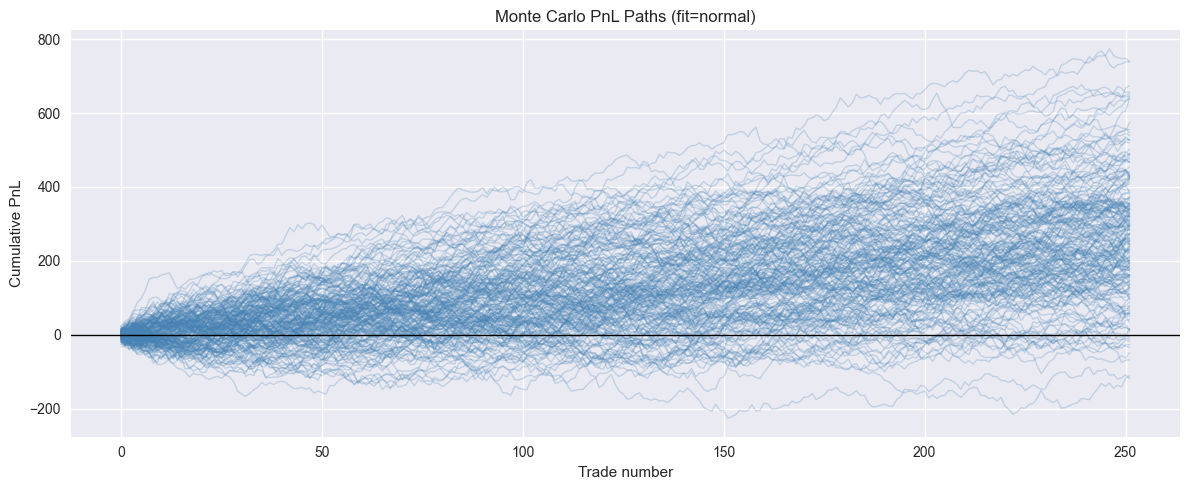

In [26]:
# Plot a subset of cumulative PnL paths
plot_n = min(200, N_PATHS)
idx = rng.choice(N_PATHS, size=plot_n, replace=False)

plt.figure(figsize=(12, 5))
plt.plot(paths[:, idx], color="steelblue", alpha=0.25, lw=1)
plt.axhline(0, color="black", lw=1)
plt.title(f"Monte Carlo PnL Paths (fit={FIT_METHOD})")
plt.xlabel("Trade number")
plt.ylabel("Cumulative PnL")
plt.tight_layout()


count    300.000000
mean     270.583012
std      161.388402
min     -118.767161
25%      163.083778
50%      271.753689
75%      358.372888
max      739.176192
dtype: float64

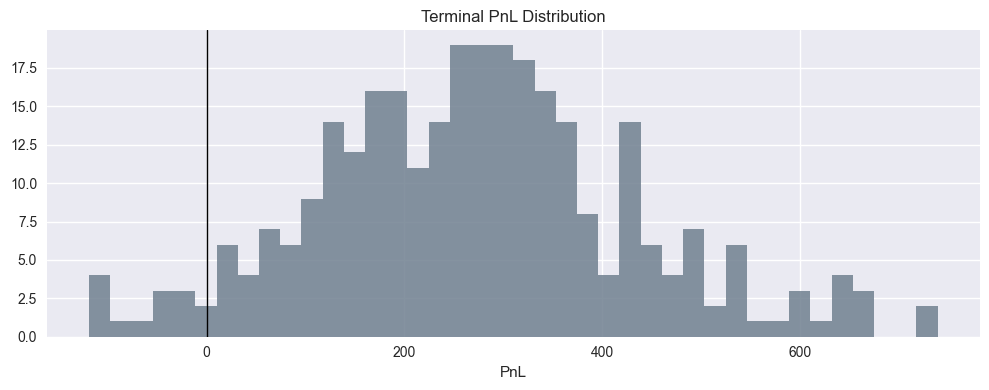

In [27]:
# Terminal PnL distribution
terminal = paths[-1]

plt.figure(figsize=(10, 4))
plt.hist(terminal, bins=40, color="slategray", alpha=0.85)
plt.axvline(0, color="black", lw=1)
plt.title("Terminal PnL Distribution")
plt.xlabel("PnL")
plt.tight_layout()

pd.Series(terminal).describe()
